# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

Matplotlib is building the font cache; this may take a moment.


In [78]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

MODEL_A = "ollama/llama2:latest" # weaker / baseline model
MODEL_B = "ollama/qwen2:latest"  # stronger / comparison model

MODEL_C = "ollama/qwen2:0.5b"  # stronger / comparison model

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [6]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

Loading dataset cais/mmlu from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

all/test-00000-of-00001.parquet:   0%|          | 0.00/3.50M [00:00<?, ?B/s]

all/validation-00000-of-00001.parquet:   0%|          | 0.00/408k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/1531 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/285 [00:00<?, ? examples/s]

Generating auxiliary_train split:   0%|          | 0/99842 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/14042 [00:00<?, ? examples/s]

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [7]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [ ]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")


MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") == "moral_disputes"
)[:100]
print(f"My subset: {len(MY_SUBSET)} questions")

high_school_geography_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "high_school_geography"
)[:70]
print(f"high_school_geography_subset: {len(high_school_geography_subset)} questions")

MY_SUBSET_2 = dataset.filter(
    lambda s: s.metadata.get("subject") == "anatomy"
)[:50]
print(f"My subset 2: {len(MY_SUBSET_2)} questions")

Astronomy: 152 questions
My subset: 100 questions
high_school_geography_subset: 70 questions
My subset 2: 50 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [9]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [10]:
logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_A,
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : ollama/llama2:latest
Accuracy: 0.5


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [12]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    if not log.samples:
        return pd.DataFrame(columns=["id", "epoch", "score", "subject"])

    rows = []
    for s in log.samples:
        rows.append({
            "id": s.id,
            "epoch": s.epoch,
            "score": 1 if s.scores["choice"].value == "C" else 0,
            "subject": s.metadata.get("subject") if s.metadata else None,
        })
    return pd.DataFrame(rows)

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score    subject
0   1      1      1  astronomy
1   2      1      0  astronomy
2   3      1      1  astronomy
3   4      1      0  astronomy
4   5      1      0  astronomy

Accuracy: 50.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [59]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    mean_accuracy = scores.mean()
    n = len(scores)

    # se = np.sqrt(mean_accuracy * (1 - mean_accuracy) / n)
    se = np.sqrt(scores.var(ddof=1) / n)
    z = stats.norm.ppf(1 - (1 - ci) / 2)

    lower_bound = mean_accuracy - z * se
    upper_bound = mean_accuracy + z * se

    return (lower_bound, mean_accuracy, upper_bound)


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    scores = np.array(df.groupby("id")["score"].mean())
    return ci_accuracy_basic(scores, ci)



In [61]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=0.01)
assert np.isclose(u95, 0.8080578932851544, atol=0.01)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.343
K=3 width: 0.227  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Output()

[03/29/26 22:07:13] ERROR    Exception in callback <_asyncio.TaskStepMethWrapper object at      ]8;id=627528;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=977026;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             0x35ddb7f70>()                                                                        
                             handle: <Handle <_asyncio.TaskStepMethWrapper object at                               
                             0x35ddb7f70>()>                                                                       
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.frame                    
                             work/Versions/3.14/lib/python3.14/asyncio/events.py", line 94, in                     
                             _run                                                                                  
                                 self._context.run(self._callback, *self._args)                                    
                                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x110c0b440> is already entered                                                    

[03/29/26 22:07:16] ERROR    Exception in callback <_asyncio.TaskStepMethWrapper object at      ]8;id=994044;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=832393;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             0x3007a5240>()                                                                        
                             handle: <Handle <_asyncio.TaskStepMethWrapper object at                               
                             0x3007a5240>()>                                                                       
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.frame                    
                             work/Versions/3.14/lib/python3.14/asyncio/events.py", line 94, in                     
                             _run                                                                                  
                                 self._context.run(self._callback, *self._args)                                    
                                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x110c0b440> is already entered                                                    

[03/29/26 22:13:29] ERROR    Task was destroyed but it is pending!                              ]8;id=515186;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=192365;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-387'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/utils.py:57> wait_for=<Task pending                            
                             name='Task-388' coro=<Kernel.shell_main() running at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/zmq/eventloop/zmqstream.py:563]>                                         

/Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/site-packages/inspect_ai/_util/json.py:56: 
RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return to_jsonable_python(x, exclude_none=True, fallback=lambda _x: None)
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

                    ERROR    Task was destroyed but it is pending!                              ]8;id=629799;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=884734;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-388' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    

                    ERROR    Task was destroyed but it is pending!                              ]8;id=710250;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=535706;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-390'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/utils.py:57> wait_for=<Task pending                            
                             name='Task-391' coro=<Kernel.shell_main() running at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/zmq/eventloop/zmqstream.py:563]>                                         

                    ERROR    Task was destroyed but it is pending!                              ]8;id=314008;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=432686;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-391' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    

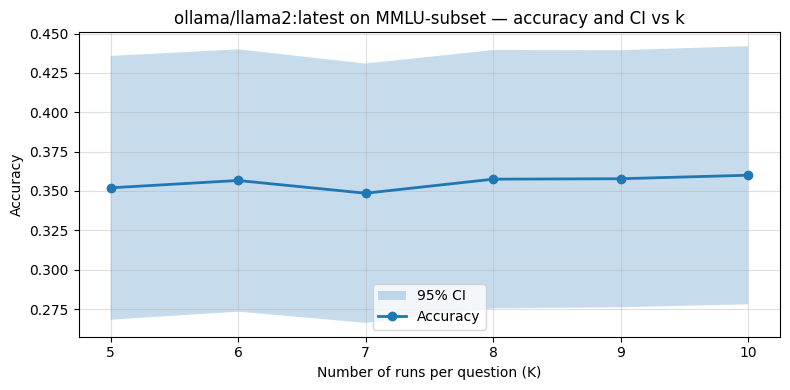

In [ ]:
k_values    = [5, 6, 7, 8, 9, 10]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

logs_max = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=10)
df_all = log_to_df(logs_max[0])

for k in k_values:
    df_k = df_all[df_all["epoch"] <= k]
    lo, acc, hi = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [70]:
for acc, k, lo, hi in zip(accuracies, k_values,  ci_lowers, ci_uppers):
    print(f"K={k}: width={hi-lo:.4f} acc={acc:.4f}")


K=5: width=0.1676 acc=0.3520
K=6: width=0.1666 acc=0.3567
K=7: width=0.1647 acc=0.3486
K=8: width=0.1641 acc=0.3575
K=9: width=0.1633 acc=0.3578
K=10: width=0.1640 acc=0.3600


Output()

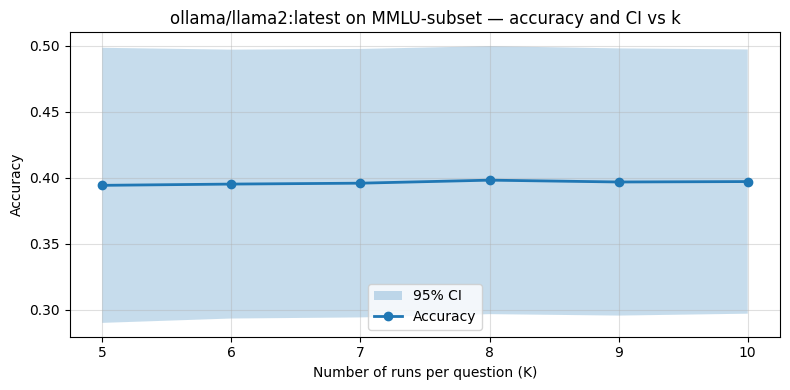

In [74]:
k_values    = [5, 6, 7, 8, 9, 10]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

logs_max = eval(mmlu_subset(high_school_geography_subset), model=MODEL_A, epochs=10)
df_all = log_to_df(logs_max[0])

for k in k_values:
    df_k = df_all[df_all["epoch"] <= k]
    lo, acc, hi = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [75]:
for acc, k, lo, hi in zip(accuracies, k_values,  ci_lowers, ci_uppers):
    print(f"K={k}: width={hi-lo:.4f} acc={acc:.4f}")


K=5: width=0.2086 acc=0.3943
K=6: width=0.2039 acc=0.3952
K=7: width=0.2036 acc=0.3959
K=8: width=0.2032 acc=0.3982
K=9: width=0.2026 acc=0.3968
K=10: width=0.2004 acc=0.3971


Output()

[03/29/26 22:45:13] ERROR    Exception in callback <_asyncio.TaskStepMethWrapper object at      ]8;id=465484;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=112030;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             0x35de6ff70>()                                                                        
                             handle: <Handle <_asyncio.TaskStepMethWrapper object at                               
                             0x35de6ff70>()>                                                                       
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.frame                    
                             work/Versions/3.14/lib/python3.14/asyncio/events.py", line 94, in                     
                             _run                                                                                  
                                 self._context.run(self._callback, *self._args)                                    
                                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x110c0b440> is already entered                                                    

[03/29/26 22:46:11] ERROR    Task was destroyed but it is pending!                              ]8;id=648094;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=415932;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-480'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/utils.py:57> wait_for=<Task pending                            
                             name='Task-481' coro=<Kernel.shell_main() running at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/zmq/eventloop/zmqstream.py:563]>                                         

/Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/site-packages/pydantic/fields.py:1443: 
RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def get_default(self) -> Any:
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

                    ERROR    Task was destroyed but it is pending!                              ]8;id=478350;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=946777;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-481' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    

...

/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/typing.py:1717: 
RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return ((p, type(p)) for p in parameters)
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

                    ERROR    Task was destroyed but it is pending!                              ]8;id=851264;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=792463;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-487' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    

[03/29/26 22:48:53] ERROR    Exception in callback <_asyncio.TaskStepMethWrapper object at      ]8;id=417715;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=367905;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             0x36077e620>()                                                                        
                             handle: <Handle <_asyncio.TaskStepMethWrapper object at                               
                             0x36077e620>()>                                                                       
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.frame                    
                             work/Versions/3.14/lib/python3.14/asyncio/events.py", line 94, in                     
                             _run                                                                                  
                                 self._context.run(self._callback, *self._args)                                    
                                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x110c0b440> is already entered                                                    

[03/29/26 22:48:57] ERROR    Task was destroyed but it is pending!                              ]8;id=683845;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=302028;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-489'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/utils.py:57> wait_for=<Task pending                            
                             name='Task-490' coro=<Kernel.shell_main() running at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/zmq/eventloop/zmqstream.py:563]>                                         

                    ERROR    Task was destroyed but it is pending!                              ]8;id=815935;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=264452;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-490' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    

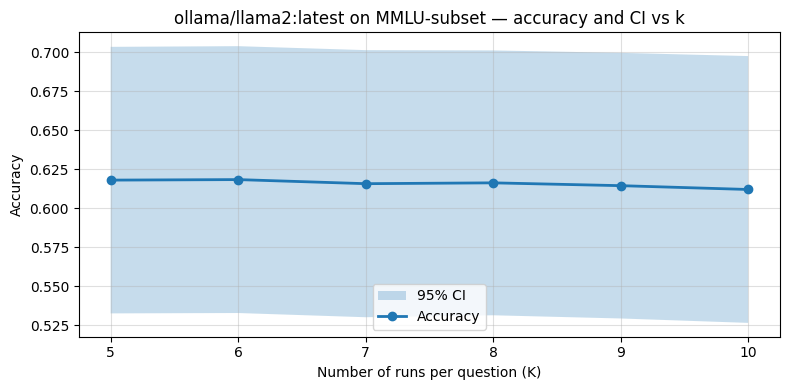

In [77]:
k_values    = [5, 6, 7, 8, 9, 10]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

logs_max = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=10)
df_all = log_to_df(logs_max[0])

for k in k_values:
    df_k = df_all[df_all["epoch"] <= k]
    lo, acc, hi = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [80]:
for acc, k, lo, hi in zip(accuracies, k_values,  ci_lowers, ci_uppers):
    print(f"K={k}: width={hi-lo:.4f} acc={acc:.4f}")


K=5: width=0.1709 acc=0.6180
K=6: width=0.1710 acc=0.6183
K=7: width=0.1712 acc=0.6157
K=8: width=0.1698 acc=0.6162
K=9: width=0.1703 acc=0.6144
K=10: width=0.1710 acc=0.6120


Output()

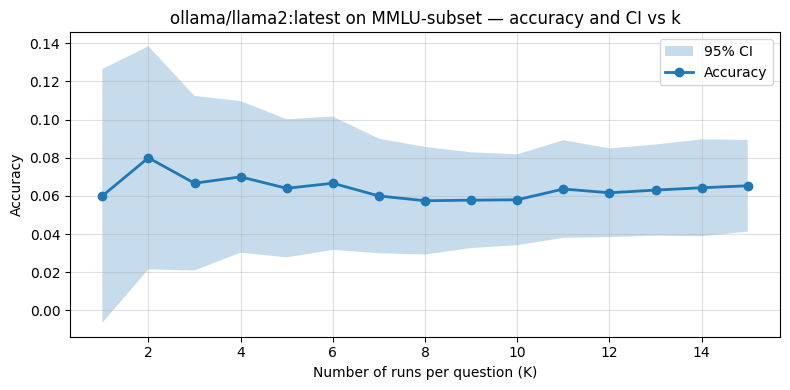

In [81]:
k_values    = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

logs_max = eval(mmlu_subset(MY_SUBSET_2), model=MODEL_C, epochs=15)
df_all = log_to_df(logs_max[0])

for k in k_values:
    df_k = df_all[df_all["epoch"] <= k]
    lo, acc, hi = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [82]:
for acc, k, lo, hi in zip(accuracies, k_values,  ci_lowers, ci_uppers):
    print(f"K={k}: width={hi-lo:.4f} acc={acc:.4f}")


K=1: width=0.1330 acc=0.0600
K=2: width=0.1169 acc=0.0800
K=3: width=0.0914 acc=0.0667
K=4: width=0.0794 acc=0.0700
K=5: width=0.0724 acc=0.0640
K=6: width=0.0698 acc=0.0667
K=7: width=0.0601 acc=0.0600
K=8: width=0.0564 acc=0.0575
K=9: width=0.0501 acc=0.0578
K=10: width=0.0476 acc=0.0580
K=11: width=0.0512 acc=0.0636
K=12: width=0.0465 acc=0.0617
K=13: width=0.0477 acc=0.0631
K=14: width=0.0508 acc=0.0643
K=15: width=0.0481 acc=0.0653


Output()

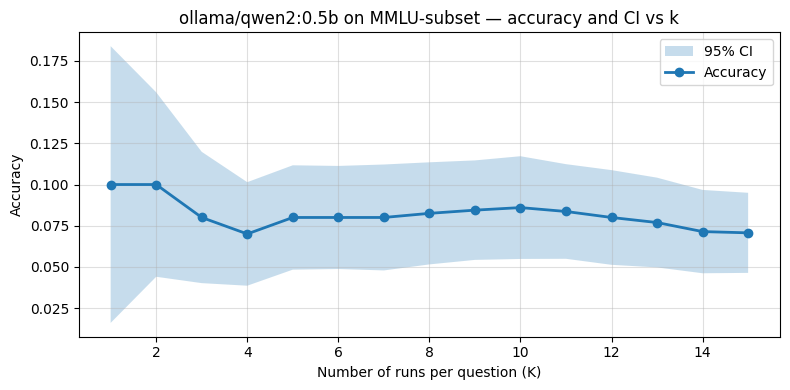

In [85]:
k_values    = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

model=MODEL_C

logs_max = eval(mmlu_subset(MY_SUBSET_2), model=model, epochs=15)
df_all = log_to_df(logs_max[0])

for k in k_values:
    df_k = df_all[df_all["epoch"] <= k]
    lo, acc, hi = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{model} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [86]:
for acc, k, lo, hi in zip(accuracies, k_values,  ci_lowers, ci_uppers):
    print(f"K={k}: width={hi-lo:.4f} acc={acc:.4f}")


K=1: width=0.1680 acc=0.1000
K=2: width=0.1120 acc=0.1000
K=3: width=0.0797 acc=0.0800
K=4: width=0.0629 acc=0.0700
K=5: width=0.0634 acc=0.0800
K=6: width=0.0626 acc=0.0800
K=7: width=0.0643 acc=0.0800
K=8: width=0.0620 acc=0.0825
K=9: width=0.0604 acc=0.0844
K=10: width=0.0624 acc=0.0860
K=11: width=0.0575 acc=0.0836
K=12: width=0.0575 acc=0.0800
K=13: width=0.0545 acc=0.0769
K=14: width=0.0506 acc=0.0714
K=15: width=0.0486 acc=0.0707


Output()

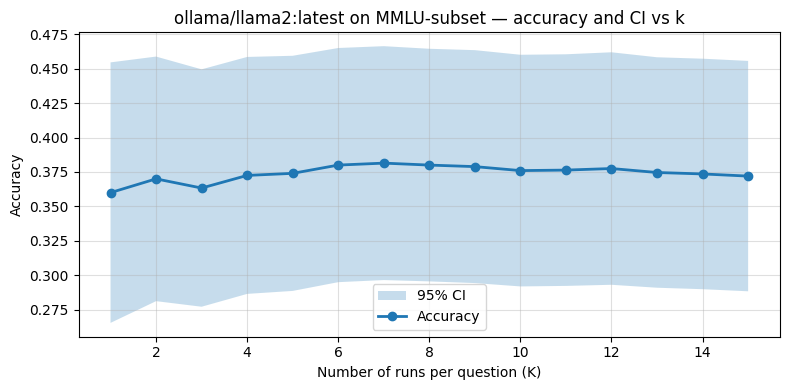

In [87]:
k_values    = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

logs_max = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=15)
df_all = log_to_df(logs_max[0])

for k in k_values:
    df_k = df_all[df_all["epoch"] <= k]
    lo, acc, hi = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [88]:
for acc, k, lo, hi in zip(accuracies, k_values,  ci_lowers, ci_uppers):
    print(f"K={k}: width={hi-lo:.4f} acc={acc:.4f}")


K=1: width=0.1891 acc=0.3600
K=2: width=0.1775 acc=0.3700
K=3: width=0.1723 acc=0.3633
K=4: width=0.1720 acc=0.3725
K=5: width=0.1707 acc=0.3740
K=6: width=0.1700 acc=0.3800
K=7: width=0.1698 acc=0.3814
K=8: width=0.1689 acc=0.3800
K=9: width=0.1691 acc=0.3789
K=10: width=0.1682 acc=0.3760
K=11: width=0.1681 acc=0.3764
K=12: width=0.1688 acc=0.3775
K=13: width=0.1673 acc=0.3746
K=14: width=0.1673 acc=0.3736
K=15: width=0.1672 acc=0.3720


Output()

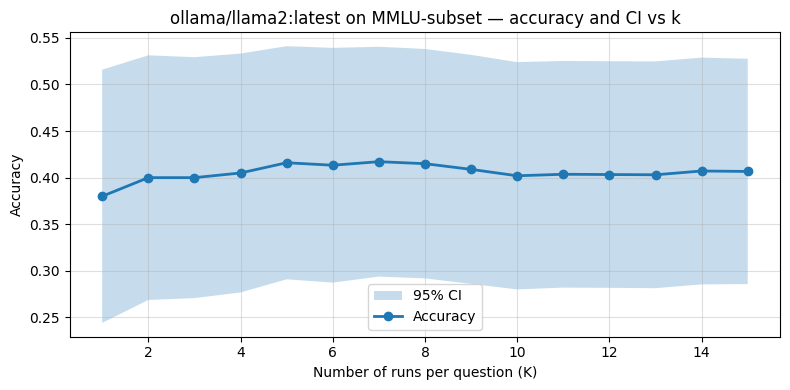

In [83]:
k_values    = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

logs_max = eval(mmlu_subset(MY_SUBSET_2), model=MODEL_A, epochs=15)
df_all = log_to_df(logs_max[0])

for k in k_values:
    df_k = df_all[df_all["epoch"] <= k]
    lo, acc, hi = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [84]:
for acc, k, lo, hi in zip(accuracies, k_values,  ci_lowers, ci_uppers):
    print(f"K={k}: width={hi-lo:.4f} acc={acc:.4f}")


K=1: width=0.2718 acc=0.3800
K=2: width=0.2627 acc=0.4000
K=3: width=0.2586 acc=0.4000
K=4: width=0.2565 acc=0.4050
K=5: width=0.2503 acc=0.4160
K=6: width=0.2520 acc=0.4133
K=7: width=0.2467 acc=0.4171
K=8: width=0.2463 acc=0.4150
K=9: width=0.2459 acc=0.4089
K=10: width=0.2440 acc=0.4020
K=11: width=0.2433 acc=0.4036
K=12: width=0.2433 acc=0.4033
K=13: width=0.2435 acc=0.4031
K=14: width=0.2435 acc=0.4071
K=15: width=0.2419 acc=0.4067


Output()

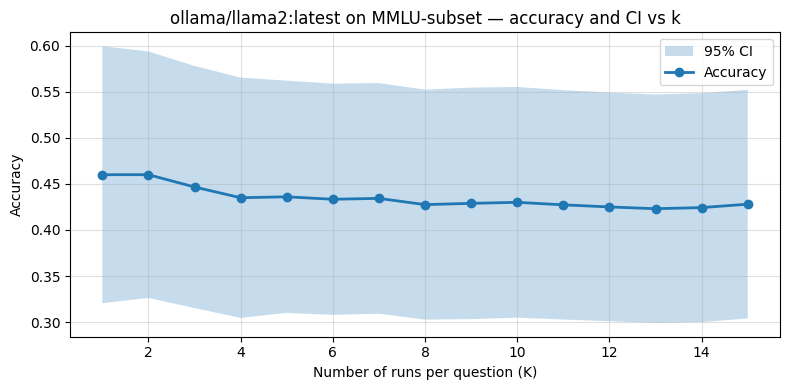

In [89]:
k_values    = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

logs_max = eval(mmlu_subset(MY_SUBSET_2), model=MODEL_A, epochs=15)
df_all = log_to_df(logs_max[0])

for k in k_values:
    df_k = df_all[df_all["epoch"] <= k]
    lo, acc, hi = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [90]:
for acc, k, lo, hi in zip(accuracies, k_values,  ci_lowers, ci_uppers):
    print(f"K={k}: width={hi-lo:.4f} acc={acc:.4f}")


K=1: width=0.2791 acc=0.4600
K=2: width=0.2676 acc=0.4600
K=3: width=0.2630 acc=0.4467
K=4: width=0.2609 acc=0.4350
K=5: width=0.2521 acc=0.4360
K=6: width=0.2511 acc=0.4333
K=7: width=0.2504 acc=0.4343
K=8: width=0.2497 acc=0.4275
K=9: width=0.2514 acc=0.4289
K=10: width=0.2505 acc=0.4300
K=11: width=0.2490 acc=0.4273
K=12: width=0.2482 acc=0.4250
K=13: width=0.2479 acc=0.4231
K=14: width=0.2486 acc=0.4243
K=15: width=0.2482 acc=0.4280


---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

1. The most significant narrowing happens between K=1 and K=5. For example, on MY_SUBSET_2 (anatomy subset) with MODEL_C (qwen2:0.5b) the width drops from 0.168 (K=1) to 0.063 (K=5) — a 2.5x reduction. After K=5 the gains are minimal (0.063 -> 0.049 by K=15). On MY_SUBSET_2 with MODEL_A (llama2), the effect is weaker, but mostly the same: 0.279 -> ~0.250 from K=1 to K=5-6 and then hovers at 0.250. Beyond ~5 epochs, additional runs are not worth the compute cost.

2. As I see it, more K changes confidence, but not the estimate. Accuracy stays roughly stable across K in every experiment: MODEL_C on MY_SUBSET_2 hovers at 0.06, llama2 on MY_SUBSET_2 at 0.4. The band narrows but the center line doesn't drift.

3. Budget is better spent on more questions than more epochs. K=5-7 suffices to reduce within-question noise, but after that each additional epoch adds very little. The remaining budget should go toward a larger question set, which addresses the irreducible variance component that extra epochs cannot reduce.

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

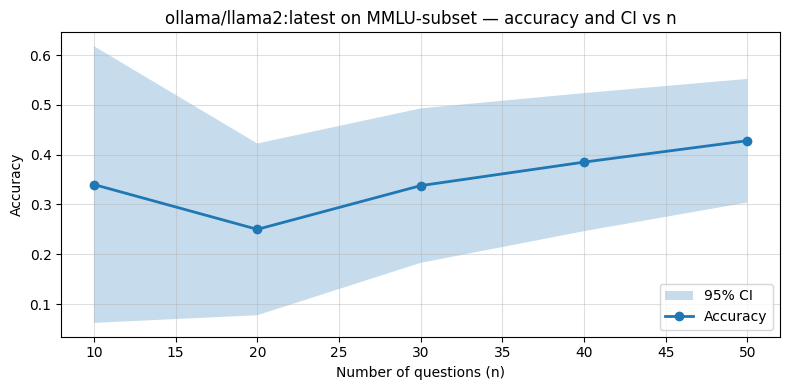

In [91]:
question_ids = df_all["id"].unique()
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies    = []
ci_lowers     = []
ci_uppers     = []

for n in dataset_sizes:
    subset_ids = question_ids[:n]
    df_n = df_all[df_all["id"].isin(subset_ids)]
    lo, acc, hi = ci_accuracy(df_n)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

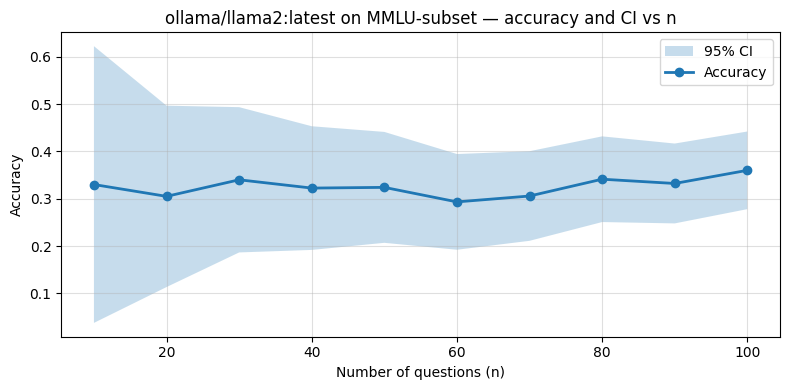

In [92]:
from inspect_ai.log import read_eval_log

log = read_eval_log("logs/2026-03-29T19-04-18-00-00_mmlu-subset_L947APFdj5FtNYSFFxV6bD.eval")
df_moral = log_to_df(log)

question_ids = df_moral["id"].unique()
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies    = []
ci_lowers     = []
ci_uppers     = []

for n in dataset_sizes:
    subset_ids = question_ids[:n]
    df_n = df_moral[df_moral["id"].isin(subset_ids)]
    lo, acc, hi = ci_accuracy(df_n)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**

1. Around n=40–50. Before that accuracy fluctuates widely. After, it stays within a narrow band.

2. I tested on MY_SUBSET (has 100 questions) and MY_SUBSET_2 (has 50 questions). 100 is roughly twice the stabilization threshold (~50). So yes, I'm in the reliable region, though more questions would narrow the CI further.

3. K reduces within-question noise, but it gives little improvement after K~5. n reduces between-question variance. This is a more powerful lever: CI shrinks proportionally to 1/√n with no ceiling effect. So evaluation budget is better spent on more questions than more epochs.



## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [93]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"
    
    _, p_value  = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff   = (scores1 - scores2).mean()
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [94]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


/Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [95]:
p, d, sig = compare_models_paired(MODEL_A, MODEL_B, MY_SUBSET)
print(f"p-value: {p:.4f}")
print(f"Mean difference (A - B): {d:.4f}")
print(f"Significant at α=0.05: {sig}")


Output()

  Running ollama/llama2:latest ...


Output()

  Running ollama/qwen2:latest ...


p-value: 0.0022
Mean difference (A - B): -0.2000
Significant at α=0.05: True


In [96]:
p, d, sig = compare_models_paired(MODEL_A, MODEL_B, MY_SUBSET, epochs_a=5, epochs_b=5)
print(f"p-value: {p:.4f}")
print(f"Mean difference (A - B): {d:.4f}")
print(f"Significant at α=0.05: {sig}")


Output()

  Running ollama/llama2:latest ...


  Running ollama/qwen2:latest ...


Output()

p-value: 0.0001
Mean difference (A - B): -0.2220
Significant at α=0.05: True


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**

1. With 1 epoch: p-value = 0.0022, mean difference (A − B) = −0.20. With 5 epochs: p-value = 0.0001, mean difference = −0.222. In both cases qwen2 outperforms llama2.

2. The gap is statistically significant (p << 0.05) and IMO matters in practice: a 20+ percentage point difference in accuracy is large enough. qwen2 is clearly better than llama2 on moral_disputes (MY_SUBSET).

3. More questions would narrow the CI but likely wouldn't change the conclusion (the effect is already strong). A different subject might change the magnitude (or even the direction) of the gap. A different model pair would most likely change the result: for example, comparing two models of similar size/capability could produce a smaller (possibly non-significant) difference.



## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Use `ci_accuracy_basic` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [ ]:
from inspect_ai.log import read_eval_log

# epochs=1 runs from Assignment 5
log_a = read_eval_log("logs/2026-03-29T21-59-24-00-00_mmlu-subset_SyuWHqKJzXGag2wjftKMFF.eval")
log_b = read_eval_log("logs/2026-03-29T22-00-33-00-00_mmlu-subset_6nDhXbP8onyXrauRgcijo6.eval")

scores_a = log_to_df(log_a).groupby("id")["score"].mean().sort_index().values
scores_b = log_to_df(log_b).groupby("id")["score"].mean().sort_index().values

diffs = scores_a - scores_b
lo, mean_diff, hi = ci_accuracy_basic(diffs)
print(f"95% CI on (A - B): [{lo:.4f}, {hi:.4f}]")
print(f"Mean difference: {mean_diff:.4f}")
print(f"Contains zero: {lo <= 0 <= hi}")


95% CI on (A - B): [-0.3246, -0.0754]
Mean difference: -0.2000
Contains zero: False


In [99]:
from inspect_ai.log import read_eval_log

# epochs=1 runs from Assignment 5
log_a = read_eval_log("logs/2026-03-29T22-03-45-00-00_mmlu-subset_jbTMcxyoqZhGpcHWQz2hiW.eval")
log_b = read_eval_log("logs/2026-03-29T22-08-53-00-00_mmlu-subset_mkcnt7rEWN656ZJhWG9hZ5.eval")

scores_a = log_to_df(log_a).groupby("id")["score"].mean().sort_index().values
scores_b = log_to_df(log_b).groupby("id")["score"].mean().sort_index().values

diffs = scores_a - scores_b
lo, mean_diff, hi = ci_accuracy_basic(diffs)
print(f"95% CI on (A - B): [{lo:.4f}, {hi:.4f}]")
print(f"Mean difference: {mean_diff:.4f}")
print(f"Contains zero: {lo <= 0 <= hi}")


95% CI on (A - B): [-0.3280, -0.1160]
Mean difference: -0.2220
Contains zero: False


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**

1. Interval with 1 epoch is [-0.3246, -0.0754], with 5 epochs is [-0.3280, -0.1160]. Neither interval contains zero. It means qwen2 outperforms llama2 by 11–33 percentage points.

2. Yes, they tell the same story: in Assignment 5, p-value < 0.05 => the difference is significant. Here, the CI excludes zero => the difference is also significant. 

3. The interval is more informative. The p-value only answers "is there a difference?", while the CI answers "how large is the difference and what is the range?". For example, p=0.002 says "the gap is significant" but doesn't say whether it's tiny or huge. The CI [-0.33, -0.11] tells us qwen2 is better by at least 11% and no more than 33%.

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [100]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """

    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])

    mean_a = df_a.groupby("id")["score"].mean()
    mean_b = df_b.groupby("id")["score"].mean()

    sigma2_a = df_a.groupby("id")["score"].var(ddof=0).mean()
    sigma2_b = df_b.groupby("id")["score"].var(ddof=0).mean()

    diffs = mean_a - mean_b
    omega2 = diffs.var(ddof=0) - sigma2_a / df_a.groupby("id").size().iloc[0] - sigma2_b / df_b.groupby("id").size().iloc[0]
    omega2 = max(omega2, 0.0)

    return {
        "omega2":   omega2,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [101]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.2483
sigma2_A = 0.0333
sigma2_B = 0.0167

With n=100 questions -> MDE = 15.3%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**

1. MDE = 15.3% for MY_SUBSET (100 questions). I think this is a quite large gap: it means our evaluation can only detect differences of 15+%. For comparing very different models this is fine, but for comparing similar models with small differences it would be insufficient.

2. Our MDE (15.3%) is smaller than the observed gap (~22%), so our earlier result is on solid ground. But the lower bound of the CI (11%) is below the MDE. It means that if the true difference is closer to 11%, we might not reliably reproduce this finding with a different set of 100 questions. To be more confident, we would need more questions to bring the MDE below 11%.

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [102]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    n = (z_alpha + z_beta) ** 2 * (omega2 + sigma2_a / ka + sigma2_b / kb) / delta ** 2
    return int(np.ceil(n))


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 937
Round-trip check passed!


In [ ]:
n_5 = required_sample_size(delta=0.05, **params)
n_10 = required_sample_size(delta=0.10, **params)
print(f"Questions needed to detect 5% gap: {n_5}")
print(f"Questions needed to detect 10% gap: {n_10}")


Questions needed to detect 5% gap: 937
Questions needed to detect 10% gap: 235


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**

1. 937 questions for a 5% gap, 235 for a 10% gap.

2. MY_SUBSET has 100 questions which is less than 235, so it's not enough to detect even a 10% gap. It worked for us because the actual gap between llama2 and qwen2 is large, but for comparing more similar models, MY_SUBSET would need to be much bigger.

## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [ ]:
SINGLE_ANSWER_TEMPLATE_COT = r"""
Answer the following multiple choice question. The last line of your response should be of the following format: 'ANSWER: LETTER' (without quotes) where LETTER is one of {letters}. Think step by step before answering.

{question}

{choices}
""".strip()

@task
def mmlu_subset_cot(subset):
    return Task(
        dataset=subset,
        solver=[multiple_choice(template=SINGLE_ANSWER_TEMPLATE_COT)],
        scorer=choice()
    )

In [ ]:
# Baseline (without CoT)
logs_base = eval(mmlu_subset(MY_SUBSET), model=MODEL_B)
scores_base = log_to_df(logs_base[0]).groupby("id")["score"].mean().sort_index().values

# Chain-of-thought
logs_cot = eval(mmlu_subset_cot(MY_SUBSET), model=MODEL_B)
scores_cot = log_to_df(logs_cot[0]).groupby("id")["score"].mean().sort_index().values

# Paired t-test
p, d, sig = significance_by_paired_ttest(scores_cot, scores_base)
print(f"CoT accuracy: {scores_cot.mean():.3f}")
print(f"Baseline accuracy: {scores_base.mean():.3f}")
print(f"Mean difference (CoT - baseline): {d:.4f}")
print(f"p-value: {p:.4f}")
print(f"Significant: {sig}")


Output()

Output()

[03/30/26 23:19:10] ERROR    Exception in callback <_asyncio.TaskStepMethWrapper object at      ]8;id=379217;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=889989;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             0x367039c90>()                                                                        
                             handle: <Handle <_asyncio.TaskStepMethWrapper object at                               
                             0x367039c90>()>                                                                       
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.frame                    
                             work/Versions/3.14/lib/python3.14/asyncio/events.py", line 94, in                     
                             _run                                                                                  
                                 self._context.run(self._callback, *self._args)                                    
                                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x110c0b440> is already entered                                                    

[03/30/26 23:19:12] ERROR    Exception in callback <_asyncio.TaskStepMethWrapper object at      ]8;id=988255;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=112263;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             0x366e25bd0>()                                                                        
                             handle: <Handle <_asyncio.TaskStepMethWrapper object at                               
                             0x366e25bd0>()>                                                                       
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.frame                    
                             work/Versions/3.14/lib/python3.14/asyncio/events.py", line 94, in                     
                             _run                                                                                  
                                 self._context.run(self._callback, *self._args)                                    
                                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x110c0b440> is already entered                                                    

[03/30/26 23:19:26] ERROR    Task was destroyed but it is pending!                              ]8;id=74277;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=417039;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-654'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/utils.py:57> wait_for=<Task pending                            
                             name='Task-655' coro=<Kernel.shell_main() running at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/zmq/eventloop/zmqstream.py:563]>                                         

/Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/site-packages/inspect_ai/log/_log.py:534: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  sample: EvalSample = handler(data)


                    ERROR    Task was destroyed but it is pending!                              ]8;id=293815;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=338753;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-655' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    

                    ERROR    Task was destroyed but it is pending!                              ]8;id=610531;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=461089;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-657'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/utils.py:57> wait_for=<Task pending                            
                             name='Task-658' coro=<Kernel.shell_main() running at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/zmq/eventloop/zmqstream.py:563]>                                         

                    ERROR    Task was destroyed but it is pending!                              ]8;id=685618;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=406340;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             task: <Task pending name='Task-658' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /Users/alinaerokhina/ai-safety-evals-course/.venv/lib/python3.14/s                    
                             ite-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>                    

CoT accuracy: 0.540
Baseline accuracy: 0.630
Mean difference (CoT - baseline): -0.0900
p-value: 0.0948
Significant: False


In [ ]:
# Baseline (without CoT)
logs_base = eval(mmlu_subset(MY_SUBSET), model=MODEL_A)
scores_base = log_to_df(logs_base[0]).groupby("id")["score"].mean().sort_index().values

# Chain-of-thought
logs_cot = eval(mmlu_subset_cot(MY_SUBSET), model=MODEL_A)
scores_cot = log_to_df(logs_cot[0]).groupby("id")["score"].mean().sort_index().values

# Paired t-test
p, d, sig = significance_by_paired_ttest(scores_cot, scores_base)
print(f"CoT accuracy: {scores_cot.mean():.3f}")
print(f"Baseline accuracy: {scores_base.mean():.3f}")
print(f"Mean difference (CoT - baseline): {d:.4f}")
print(f"p-value: {p:.4f}")
print(f"Significant: {sig}")


Output()

Output()

CoT accuracy: 0.280
Baseline accuracy: 0.340
Mean difference (CoT - baseline): -0.0600
p-value: 0.2224
Significant: False


In [110]:
high_school_mathematics_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "high_school_mathematics"
)[:100]
print(f"high_school_mathematics_subset: {len(high_school_mathematics_subset)} questions")

high_school_mathematics_subset: 100 questions


In [ ]:
# Baseline (without CoT)
logs_base = eval(mmlu_subset(high_school_mathematics_subset), model=MODEL_B)
scores_base = log_to_df(logs_base[0]).groupby("id")["score"].mean().sort_index().values

# Chain-of-thought
logs_cot = eval(mmlu_subset_cot(high_school_mathematics_subset), model=MODEL_B)
scores_cot = log_to_df(logs_cot[0]).groupby("id")["score"].mean().sort_index().values

# Paired t-test
p, d, sig = significance_by_paired_ttest(scores_cot, scores_base)
print(f"CoT accuracy: {scores_cot.mean():.3f}")
print(f"Baseline accuracy: {scores_base.mean():.3f}")
print(f"Mean difference (CoT - baseline): {d:.4f}")
print(f"p-value: {p:.4f}")
print(f"Significant: {sig}")


Output()

Output()

[03/30/26 23:35:05] ERROR    Exception in callback <_asyncio.TaskStepMethWrapper object at      ]8;id=715082;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=510733;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             0x300947f70>()                                                                        
                             handle: <Handle <_asyncio.TaskStepMethWrapper object at                               
                             0x300947f70>()>                                                                       
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.frame                    
                             work/Versions/3.14/lib/python3.14/asyncio/events.py", line 94, in                     
                             _run                                                                                  
                                 self._context.run(self._callback, *self._args)                                    
                                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x110c0b440> is already entered                                                    

[03/30/26 23:35:06] ERROR    Exception in callback <_asyncio.TaskStepMethWrapper object at      ]8;id=603622;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=348185;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             0x36b819e10>()                                                                        
                             handle: <Handle <_asyncio.TaskStepMethWrapper object at                               
                             0x36b819e10>()>                                                                       
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.frame                    
                             work/Versions/3.14/lib/python3.14/asyncio/events.py", line 94, in                     
                             _run                                                                                  
                                 self._context.run(self._callback, *self._args)                                    
                                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x110c0b440> is already entered                                                    

[03/30/26 23:35:08] ERROR    Exception in callback <_asyncio.TaskStepMethWrapper object at      ]8;id=507755;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py\base_events.py]8;;\:]8;id=209397;file:///opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/asyncio/base_events.py#1875\1875]8;;\
                             0x3641f8ac0>()                                                                        
                             handle: <Handle <_asyncio.TaskStepMethWrapper object at                               
                             0x3641f8ac0>()>                                                                       
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.frame                    
                             work/Versions/3.14/lib/python3.14/asyncio/events.py", line 94, in                     
                             _run                                                                                  
                                 self._context.run(self._callback, *self._args)                                    
                                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x110c0b440> is already entered                                                    

CoT accuracy: 0.580
Baseline accuracy: 0.420
Mean difference (CoT - baseline): 0.1600
p-value: 0.0107
Significant: True


In [112]:
formal_logic_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "formal_logic"
)[:100]
print(f"formal_logic_subset: {len(formal_logic_subset)} questions")

formal_logic_subset: 100 questions


In [ ]:
# Baseline (without CoT)
logs_base = eval(mmlu_subset(formal_logic_subset), model=MODEL_A)
scores_base = log_to_df(logs_base[0]).groupby("id")["score"].mean().sort_index().values

# Chain-of-thought
logs_cot = eval(mmlu_subset_cot(formal_logic_subset), model=MODEL_A)
scores_cot = log_to_df(logs_cot[0]).groupby("id")["score"].mean().sort_index().values

# Paired t-test
p, d, sig = significance_by_paired_ttest(scores_cot, scores_base)
print(f"CoT accuracy: {scores_cot.mean():.3f}")
print(f"Baseline accuracy: {scores_base.mean():.3f}")
print(f"Mean difference (CoT - baseline): {d:.4f}")
print(f"p-value: {p:.4f}")
print(f"Significant: {sig}")


Output()

Output()

CoT accuracy: 0.210
Baseline accuracy: 0.230
Mean difference (CoT - baseline): -0.0200
p-value: 0.6852
Significant: False


---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**

1. Depends on the subject. At first, I tested two models on MY_SUBSET (moral_disputes) but didn't get significant results. Probably it's because the subset is factual and CoT doesn't help much. So I decided to test on high_school_mathematics: here CoT significantly improved qwen2's accuracy by 16% (42% vs 58%, p=0.011). I also tested llama2 on formal_logic, but the results were not significant either.

2. Yes, the results surprised me — I expected CoT always improves the results. However, it's not always true. CoT helps on math because problems require step-by-step calculation — reasoning leads to the correct answer. On moral_disputes, questions are more about knowledge and judgment than reasoning chains, so extra thinking doesn't help and may even distract the model. For llama2 on formal_logic, the model is likely too weak to reason effectively even with CoT prompting.

3. I think subjects requiring multi-step reasoning (math, physics, logic) should generally benefit from CoT. But knowledge-heavy subjects (history, geography, moral disputes) likely won't, as the answer is either known or not — no amount of step-by-step reasoning helps if the knowledge is not in the model.

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [ ]:
# YOUR CODE HERE